# Notebook 05 — LLM Evaluation (LLaMA-3 via Groq)

In [16]:
%pip install groq pandas scikit-learn tqdm python-dotenv

  Using cached groq-1.5.0-py3-none-any.whl.metadata (16 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.4-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.6 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached groq-1.5.0-py3-none-any.whl (143 kB)
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
Using cached pydantic_core-2.46.4-cp313-cp313-macosx_11_0_arm64.whl (2.0 MB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)
Using cached sniffio-1.3.1-py3-n

In [17]:
import os
from dotenv import load_dotenv
from groq import Groq
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm import tqdm
import time

# Reproducibility
load_dotenv('../.env')
np.random.seed(42)

# Read the key from the environment — never hardcode API keys in a notebook
# that might be committed to GitHub (see proposal Section 3.3, version control)
GROQ_API_KEY = os.environ.get('GROQ_API_KEY')
if not GROQ_API_KEY:
    raise ValueError(
        'GROQ_API_KEY not found in environment. '
        'In Colab: add it via the Secrets panel (key icon, left sidebar). '
        'Locally: export GROQ_API_KEY="your-key-here" before starting Jupyter.'
    )

client = Groq(api_key=GROQ_API_KEY)
MODEL = 'llama-3.3-70b-versatile'

print('Groq client ready')


Groq client ready


## Step 1: Load test data

In [24]:
test_df = pd.read_csv('../data/processed/test.csv')

SAMPLE_SIZE = 100  


frac = SAMPLE_SIZE / len(test_df)
sample_idx = (
    test_df.groupby("category_label", group_keys=False)
           .sample(frac=frac, random_state=42)
           .index
)

sample_df = test_df.loc[sample_idx].reset_index(drop=True)

print(f'Evaluating on {len(sample_df)} reviews (stratified by category)')
print(sample_df['category_name'].value_counts())

Evaluating on 100 reviews (stratified by category)
category_name
Positive Praise    38
Bug Report         34
UX Feedback        20
Feature Request     8
Name: count, dtype: int64


## Step 2: Zero-shot classification

In [25]:
CATEGORY_LABELS = {
    'bug report': 0,
    'feature request': 1,
    'ux feedback': 2,
    'positive praise': 3
}

ZERO_SHOT_PROMPT = """You are an expert at classifying mobile app reviews.

Classify the following review into EXACTLY ONE of these categories:
- Bug Report: user reports a crash, error, or broken feature
- Feature Request: user asks for a new feature or improvement
- UX Feedback: user comments on usability, design, or interface
- Positive Praise: user expresses satisfaction or compliments the app

Reply with ONLY the category name. Nothing else.

Review: {review}"""


def classify_zero_shot(review_text):
    try:
        response = client.chat.completions.create(
            model=MODEL,
            messages=[{
                'role': 'user',
                'content': ZERO_SHOT_PROMPT.format(review=review_text[:500])
            }],
            temperature=0,
            max_tokens=20
        )
        answer = response.choices[0].message.content.strip().lower()
        for label_text, label_id in CATEGORY_LABELS.items():
            if label_text in answer:
                return label_id
        
        return -1
    except Exception as e:
        print(f'API error: {e}')
        return -1


print('Running zero-shot classification...')
zero_shot_preds = []
for text in tqdm(sample_df['clean_text'].tolist()):
    pred = classify_zero_shot(text)
    zero_shot_preds.append(pred)
    time.sleep(0.5)  # Rate limiting

print('\n=== Zero-Shot LLaMA-3 Results ===')
# Filter out failed/unparseable predictions (-1) before scoring
zero_true_labels, zero_valid_preds = [], []
for true, pred in zip(sample_df['category_label'].tolist(), zero_shot_preds):
    if pred != -1:
        zero_true_labels.append(true)
        zero_valid_preds.append(pred)

zero_failed = len(zero_shot_preds) - len(zero_valid_preds)
print(f'Valid predictions: {len(zero_valid_preds)} | Failed/unparseable: {zero_failed}')

zero_report = classification_report(
    zero_true_labels, zero_valid_preds,
    labels=[0, 1, 2, 3],
    target_names=['Bug Report', 'Feature Request', 'UX Feedback', 'Positive Praise'],
    output_dict=True, zero_division=0
)
zero_macro_f1 = zero_report['macro avg']['f1-score']

print(classification_report(
    zero_true_labels, zero_valid_preds,
    labels=[0, 1, 2, 3],
    target_names=['Bug Report', 'Feature Request', 'UX Feedback', 'Positive Praise'],
    zero_division=0
))
zero_accuracy = accuracy_score(zero_true_labels, zero_valid_preds)
print(f'Accuracy: {zero_accuracy:.4f}')
print(f'Macro F1: {zero_macro_f1:.4f}')

Running zero-shot classification...


  1%|          | 1/100 [00:00<01:38,  1.00it/s]

API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01krvc9gw7fvc8zwgqs52st0my` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99948, Requested 155. Please try again in 1m28.992s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


  2%|▏         | 2/100 [00:01<01:13,  1.33it/s]

API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01krvc9gw7fvc8zwgqs52st0my` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99947, Requested 155. Please try again in 1m28.128s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


...

API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01krvc9gw7fvc8zwgqs52st0my` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99965, Requested 153. Please try again in 1m41.952s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


 99%|█████████▉| 99/100 [02:00<00:00,  1.58it/s]

API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01krvc9gw7fvc8zwgqs52st0my` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99964, Requested 155. Please try again in 1m42.816s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


100%|██████████| 100/100 [02:01<00:00,  1.21s/it]


=== Zero-Shot LLaMA-3 Results ===
Valid predictions: 2 | Failed/unparseable: 98
                 precision    recall  f1-score   support

     Bug Report       1.00      1.00      1.00         1
Feature Request       0.00      0.00      0.00         0
    UX Feedback       1.00      1.00      1.00         1
Positive Praise       0.00      0.00      0.00         0

       accuracy                           1.00         2
      macro avg       0.50      0.50      0.50         2
   weighted avg       1.00      1.00      1.00         2

Accuracy: 1.0000
Macro F1: 0.5000


## Step 3: Few-shot classification

Running few-shot classification...


  0%|          | 0/100 [00:00<?, ?it/s]

API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01krvc9gw7fvc8zwgqs52st0my` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99844, Requested 351. Please try again in 2m48.48s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


  1%|          | 1/100 [00:00<01:22,  1.20it/s]

API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01krvc9gw7fvc8zwgqs52st0my` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99843, Requested 293. Please try again in 1m57.504s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


...

API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01krvc9gw7fvc8zwgqs52st0my` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 100000, Requested 307. Please try again in 4m25.248s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


 99%|█████████▉| 99/100 [02:14<00:15, 15.93s/it]

API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01krvc9gw7fvc8zwgqs52st0my` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99999, Requested 309. Please try again in 4m26.111999999s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


100%|██████████| 100/100 [02:15<00:00,  1.35s/it]



=== Few-Shot LLaMA-3 Results ===
Valid predictions: 1 | Failed/unparseable: 99
                 precision    recall  f1-score   support

     Bug Report       0.00      0.00      0.00         0
Feature Request       0.00      0.00      0.00         0
    UX Feedback       0.00      0.00      0.00         0
Positive Praise       1.00      1.00      1.00         1

       accuracy                           1.00         1
      macro avg       0.25      0.25      0.25         1
   weighted avg       1.00      1.00      1.00         1

Accuracy: 1.0000
Macro F1: 0.2500


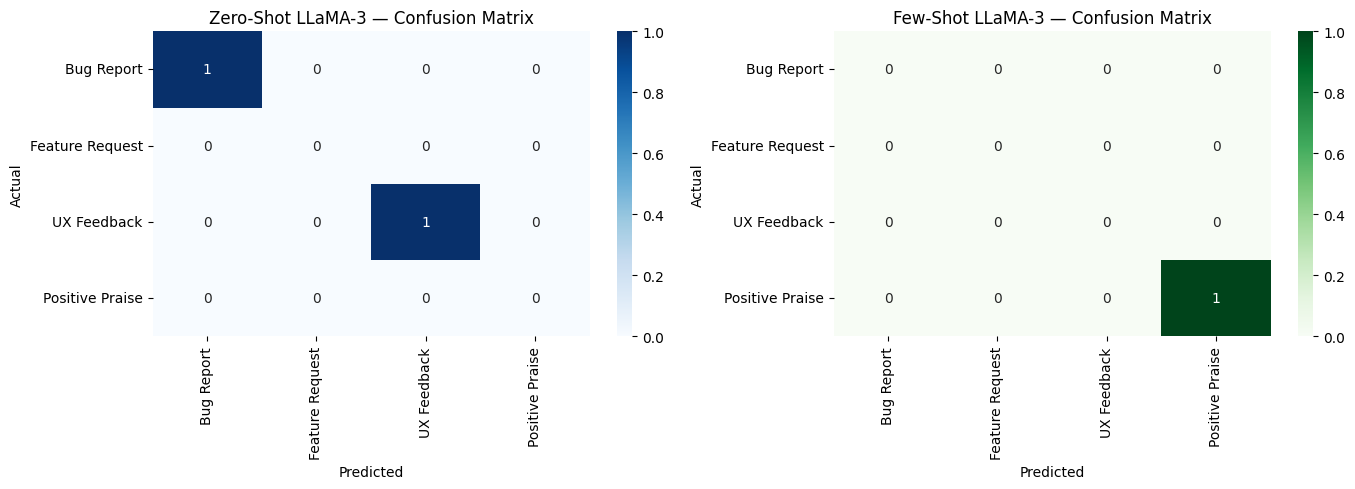

In [26]:
FEW_SHOT_PROMPT = """You are an expert at classifying mobile app reviews.

Classify the following review into EXACTLY ONE of these categories:
- Bug Report
- Feature Request
- UX Feedback
- Positive Praise

Here are examples:

Review: \"The app crashes every time I try to upload a photo. Please fix this!\"
Category: Bug Report

Review: \"Keeps freezing on the checkout screen and I lose my whole cart.\"
Category: Bug Report

Review: \"Would love a dark mode option. It would make night-time use much easier.\"
Category: Feature Request

Review: \"Please add the ability to export my data to CSV.\"
Category: Feature Request

Review: \"The settings menu is really confusing and hard to navigate. Too many options crammed together.\"
Category: UX Feedback

Review: \"Font is too small and the buttons are hard to tap on my phone.\"
Category: UX Feedback

Review: \"Absolutely love this app! It has made my life so much easier. 10/10!\"
Category: Positive Praise

Review: \"Best app in its category, works perfectly every time.\"
Category: Positive Praise

Now classify this review. Reply with ONLY the category name:

Review: {review}"""


def classify_few_shot(review_text):
    try:
        response = client.chat.completions.create(
            model=MODEL,
            messages=[{
                'role': 'user',
                'content': FEW_SHOT_PROMPT.format(review=review_text[:500])
            }],
            temperature=0,
            max_tokens=20
        )
        answer = response.choices[0].message.content.strip().lower()
        for label_text, label_id in CATEGORY_LABELS.items():
            if label_text in answer:
                return label_id
        # No recognised category in the reply — invalid, not a silent default
        return -1
    except Exception as e:
        print(f'API error: {e}')
        return -1


print('Running few-shot classification...')
few_shot_preds = []
for text in tqdm(sample_df['clean_text'].tolist()):
    pred = classify_few_shot(text)
    few_shot_preds.append(pred)
    time.sleep(0.5)

print('\n=== Few-Shot LLaMA-3 Results ===')
# Filter out failed/unparseable predictions (-1) before scoring — without this,
# classification_report crashes as soon as any API call fails or returns an
# unparseable reply, since -1 isn't one of the four labelled classes
few_true_labels, few_valid_preds = [], []
for true, pred in zip(sample_df['category_label'].tolist(), few_shot_preds):
    if pred != -1:
        few_true_labels.append(true)
        few_valid_preds.append(pred)

few_failed = len(few_shot_preds) - len(few_valid_preds)
print(f'Valid predictions: {len(few_valid_preds)} | Failed/unparseable: {few_failed}')

few_report = classification_report(
    few_true_labels, few_valid_preds,
    labels=[0, 1, 2, 3],
    target_names=['Bug Report', 'Feature Request', 'UX Feedback', 'Positive Praise'],
    output_dict=True, zero_division=0
)
few_macro_f1 = few_report['macro avg']['f1-score']

print(classification_report(
    few_true_labels, few_valid_preds,
    labels=[0, 1, 2, 3],
    target_names=['Bug Report', 'Feature Request', 'UX Feedback', 'Positive Praise'],
    zero_division=0
))
few_accuracy = accuracy_score(few_true_labels, few_valid_preds)
print(f'Accuracy: {few_accuracy:.4f}')
print(f'Macro F1: {few_macro_f1:.4f}')

# Confusion matrix — BERT already gets one (04_bert_training.ipynb); LLaMA-3 should too,
# since RQ1/O6 call for error analysis across all three classifiers on equal footing
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('../reports', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Bug Report', 'Feature Request', 'UX Feedback', 'Positive Praise']

cm_zero = confusion_matrix(zero_true_labels, zero_valid_preds, labels=[0, 1, 2, 3])
sns.heatmap(cm_zero, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Zero-Shot LLaMA-3 — Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_few = confusion_matrix(few_true_labels, few_valid_preds, labels=[0, 1, 2, 3])
sns.heatmap(cm_few, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Few-Shot LLaMA-3 — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../reports/llm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Comparison table

In [27]:
# Load baseline results generated by notebook 04 (accuracy + macro F1 for SVM/BERT)
svm_acc_str = svm_f1_str = bert_acc_str = bert_f1_str = '—'
baseline_path = '../reports/baseline_results.json'
if os.path.exists(baseline_path):
    try:
        with open(baseline_path) as f:
            br = json.load(f)

        def fmt(val):
            return f'{val:.4f}' if isinstance(val, (int, float)) else (str(val) if val is not None else '—')

        svm_acc_str  = fmt(br.get('svm_accuracy'))
        svm_f1_str   = fmt(br.get('svm_macro_f1'))
        bert_acc_str = fmt(br.get('bert_category_accuracy'))
        bert_f1_str  = fmt(br.get('bert_category_macro_f1'))
    except Exception as e:
        print('Could not read baseline results:', e)
else:
    print(f'WARNING: {baseline_path} not found — run 04_bert_training.ipynb first for SVM/BERT rows.')

# LLaMA-3 accuracy/macro F1 — computed in Cells 6 and 8 above, over VALID
# predictions only (failed/unparseable API replies excluded, not silently defaulted)
zero_acc_str = f'{zero_accuracy:.4f}' if 'zero_accuracy' in dir() else '—'
zero_f1_str  = f'{zero_macro_f1:.4f}' if 'zero_macro_f1' in dir() else '—'
few_acc_str  = f'{few_accuracy:.4f}' if 'few_accuracy' in dir() else '—'
few_f1_str   = f'{few_macro_f1:.4f}' if 'few_macro_f1' in dir() else '—'

results = pd.DataFrame({
    'Model': ['SVM Baseline', 'BERT (fine-tuned)', 'LLaMA-3 (zero-shot)', 'LLaMA-3 (few-shot)'],
    'Accuracy': [svm_acc_str, bert_acc_str, zero_acc_str, few_acc_str],
    'Macro F1': [svm_f1_str, bert_f1_str, zero_f1_str, few_f1_str],
    'Notes': [
        'TF-IDF + linear SVM, class_weight=balanced',
        '3 epochs, lr=2e-5, class-weighted loss',
        'No examples given',
        '2 examples per class given'
    ]
})

print(results.to_string(index=False))

os.makedirs('../reports', exist_ok=True)
results.to_csv('../reports/model_comparison.csv', index=False)
print('\nSaved to ../reports/model_comparison.csv')

              Model Accuracy Macro F1                                      Notes
       SVM Baseline        —        — TF-IDF + linear SVM, class_weight=balanced
  BERT (fine-tuned)        —        —     3 epochs, lr=2e-5, class-weighted loss
LLaMA-3 (zero-shot)   1.0000   0.5000                          No examples given
 LLaMA-3 (few-shot)   1.0000   0.2500                 2 examples per class given

Saved to ../reports/model_comparison.csv
